
Godišnji BDP
   year      gdp
0  1995  30194.9
1  1996  32039.5
2  1997  34015.6
3  1998  34781.6
4  1999  34486.4

Broj redaka: 31
Stupci: ['year', 'gdp']

Godišnji HICP
   year   hicp
0  1998  63.97
1  1999  66.37
2  2000  69.32
3  2001  72.28
4  2002  74.11

Broj redaka: 28
Stupci: ['year', 'hicp']

Godišnja nezaposlenost
   year  unemployment
0  2009           9.2
1  2010          11.7
2  2011          13.7
3  2012          16.1
4  2013          17.3

Broj redaka: 17
Stupci: ['year', 'unemployment']

Zajednički godišnji skup podataka
   year      gdp    hicp  unemployment
0  2009  46606.4   91.56           9.2
1  2010  45983.8   92.55          11.7
2  2011  45932.8   94.59          13.7
3  2012  44905.0   97.76          16.1
4  2013  44845.0  100.04          17.3

Broj redaka: 17
Stupci: ['year', 'gdp', 'hicp', 'unemployment']

Deskriptivna statistika - godišnji podaci
                gdp        hicp  unemployment
count     17.000000   17.000000     17.000000
mean   50560.941176  

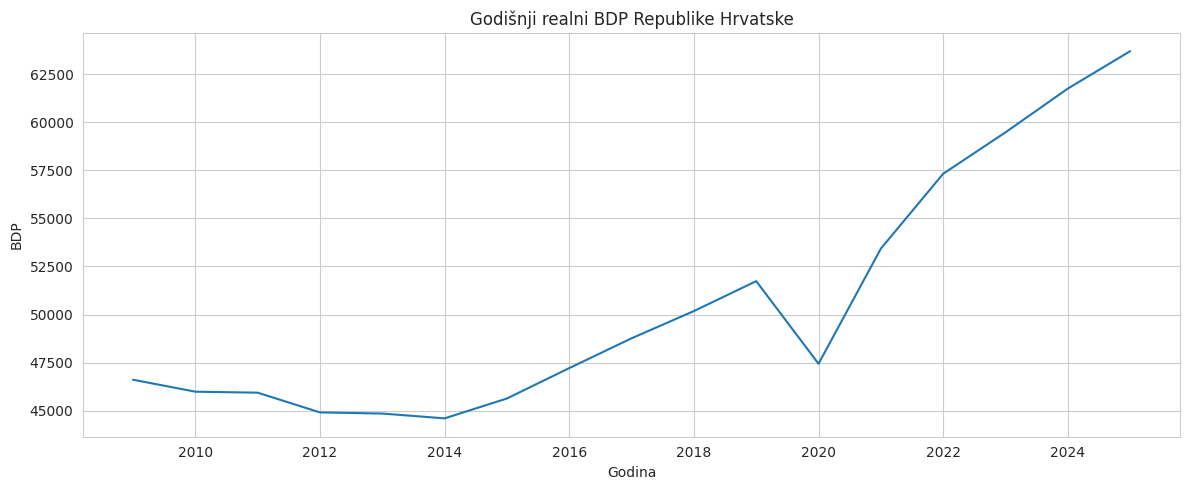

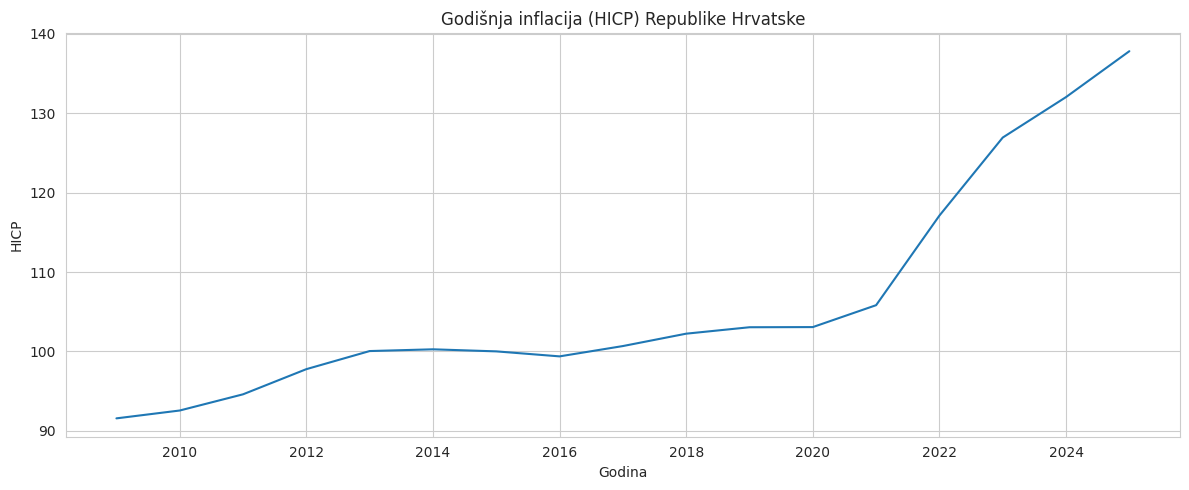

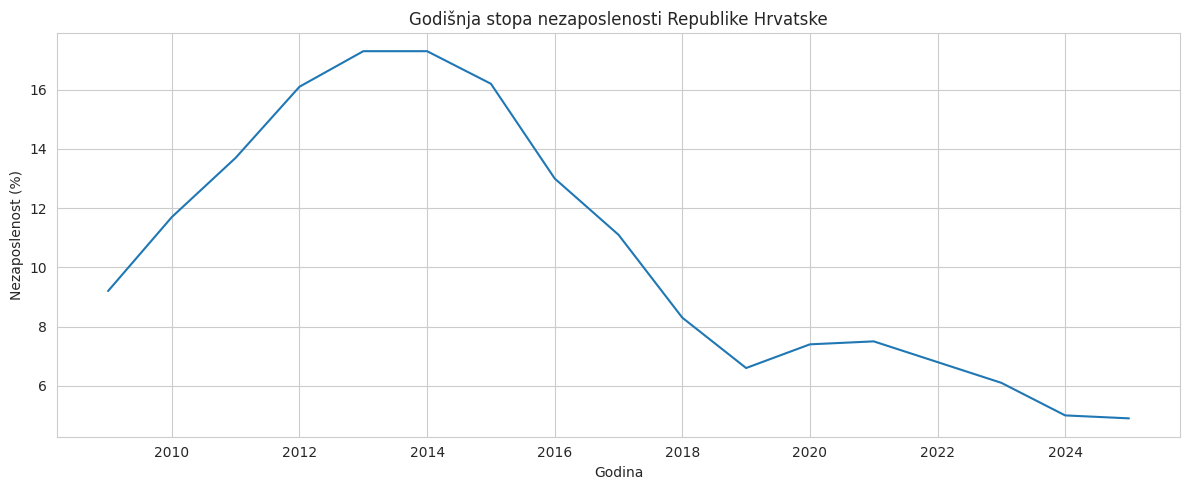


Pearsonova korelacijska matrica - godišnji podaci
                   gdp      hicp  unemployment
gdp           1.000000  0.949493     -0.822116
hicp          0.949493  1.000000     -0.657430
unemployment -0.822116 -0.657430      1.000000


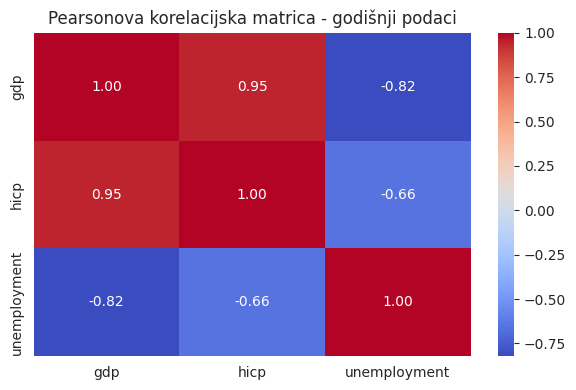


Rezultati testiranja razlike BDP-a između razdoblja
                  test  statistic   p_value
0         Welch t-test  -2.623082  0.043499
1  Mann-Whitney U test   3.000000  0.055556


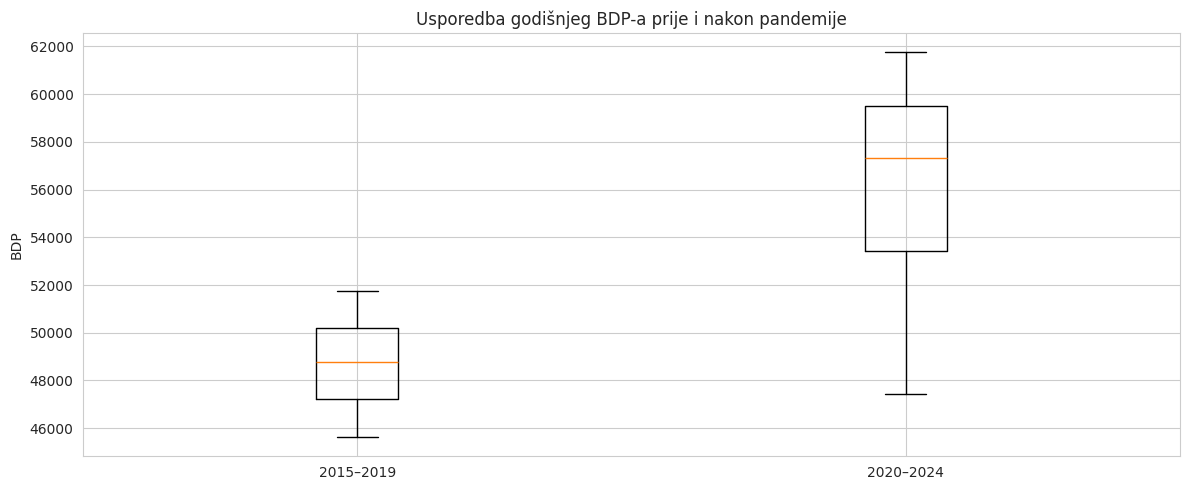


DIJAGNOSTIKA ZA KVARTALNU NEZAPOSLENOST
Ključevi JSON odgovora: dict_keys(['version', 'class', 'label', 'source', 'updated', 'value', 'status', 'id', 'size', 'dimension', 'extension'])
Broj zapisa u 'value': 68
Dimension keys: dict_keys(['freq', 's_adj', 'age', 'unit', 'sex', 'geo', 'time'])
Prvih 10 time oznaka: [('2003-Q1', 0), ('2003-Q2', 1), ('2003-Q3', 2), ('2003-Q4', 3), ('2004-Q1', 4), ('2004-Q2', 5), ('2004-Q3', 6), ('2004-Q4', 7), ('2005-Q1', 8), ('2005-Q2', 9)]

Kvartalni BDP - sirovi podaci
      time     gdp
0  1995-Q1  7541.7
1  1995-Q2  7523.3
2  1995-Q3  7309.0
3  1995-Q4  7834.8
4  1996-Q1  8101.6

Broj redaka: 124
Stupci: ['time', 'gdp']

Mjesečni HICP - sirovi podaci
      time   hicp
0  1998-01  62.88
1  1998-02  63.17
2  1998-03  63.44
3  1998-04  63.74
4  1998-05  64.16

Broj redaka: 336
Stupci: ['time', 'hicp']

Kvartalna nezaposlenost - sirovi podaci
      time  unemployment
0  2009-Q1           8.8
1  2009-Q2           9.1
2  2009-Q3           9.3
3  2009-Q4   

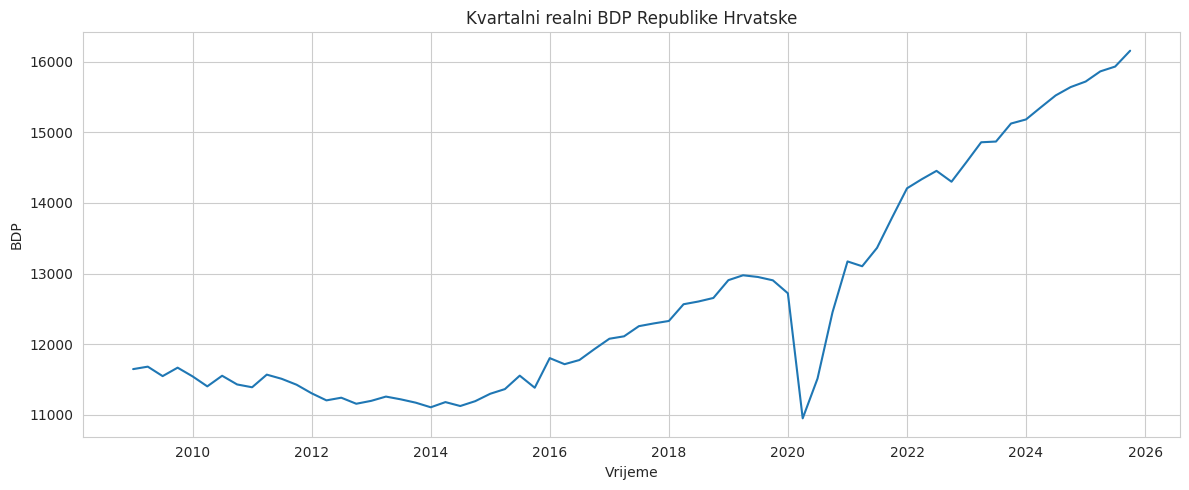

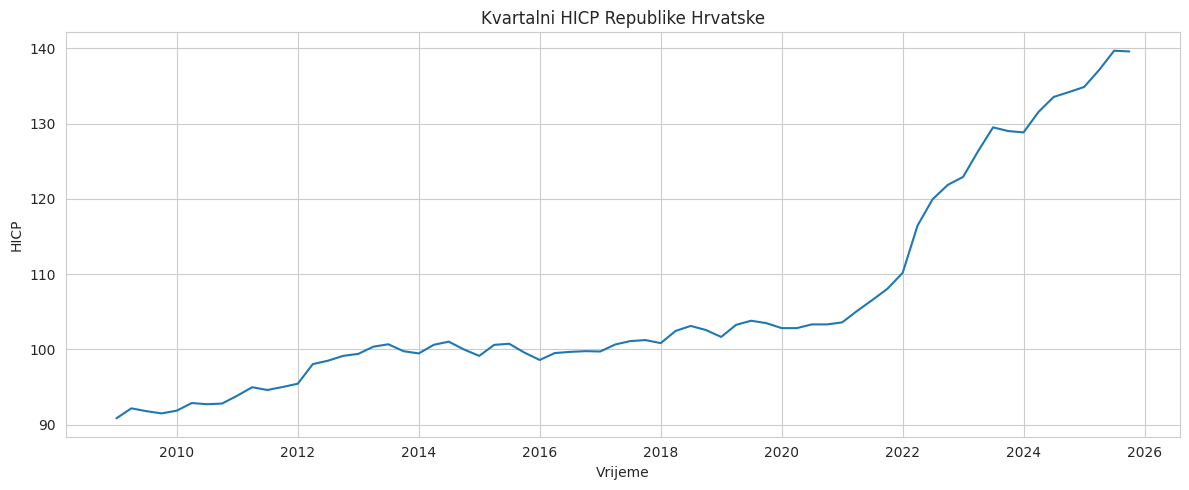

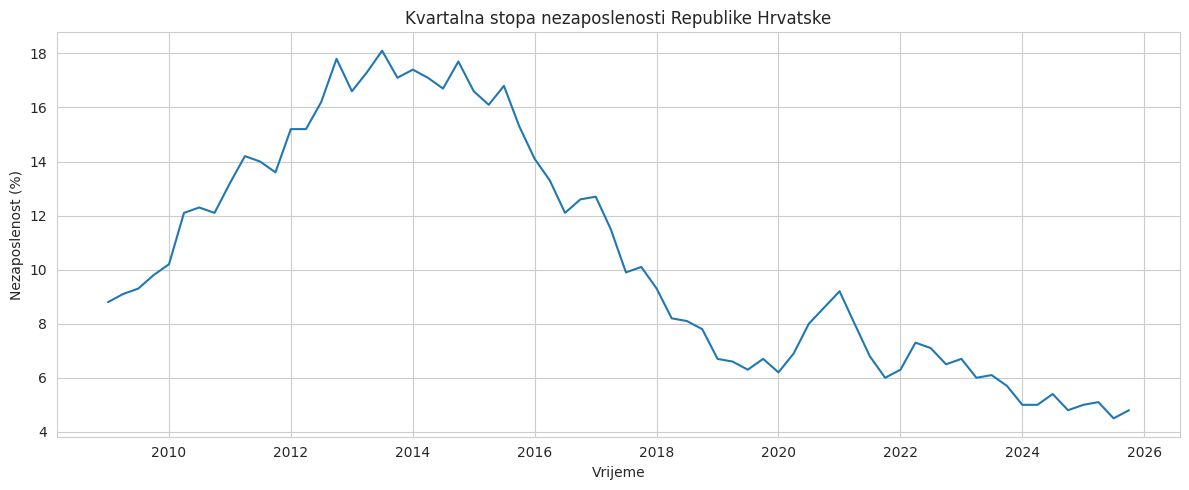


Pearsonova korelacijska matrica - kvartalni podaci
                   gdp      hicp  unemployment
gdp           1.000000  0.940248     -0.812443
hicp          0.940248  1.000000     -0.648422
unemployment -0.812443 -0.648422      1.000000


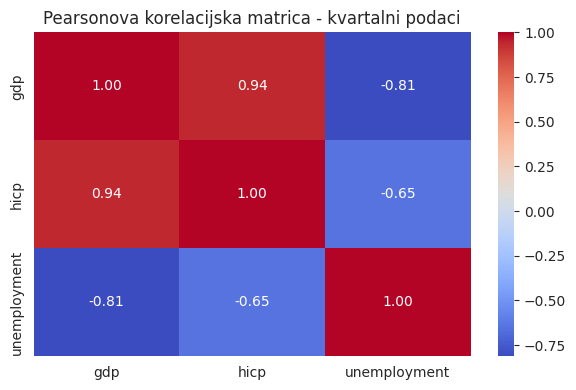

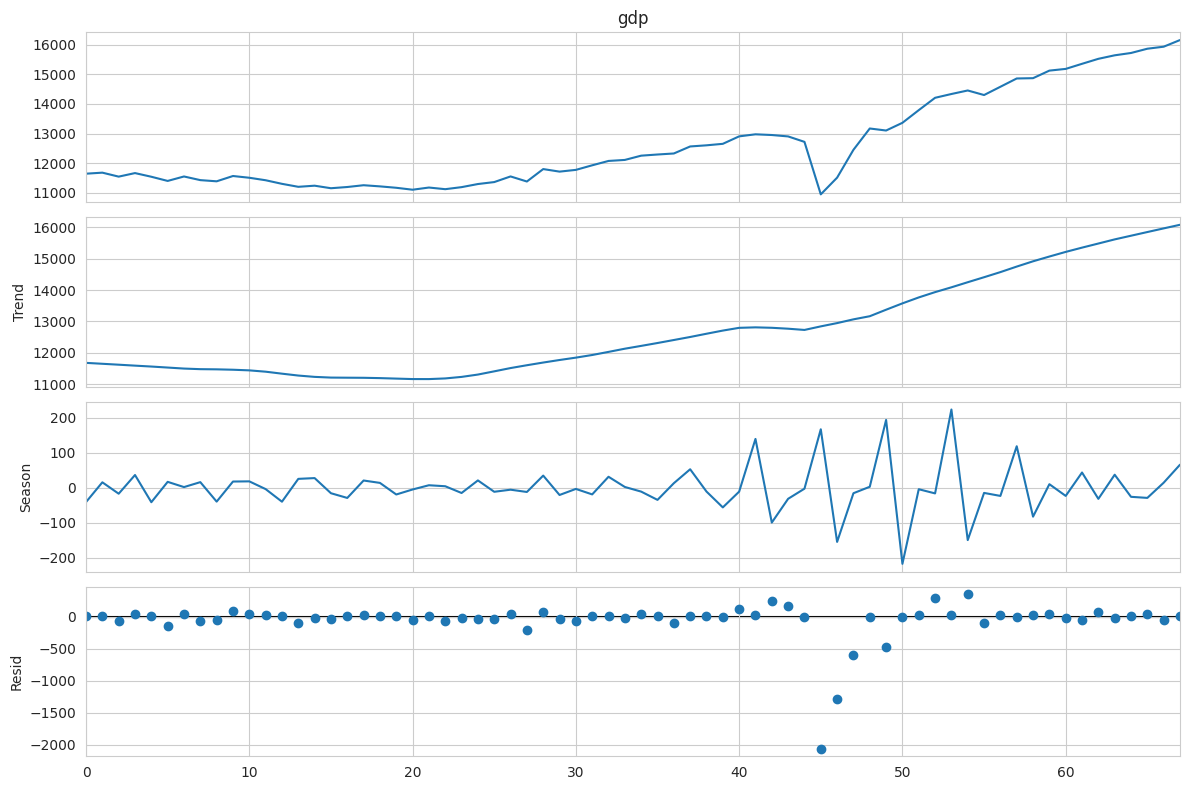


Veličina train skupa: 60
Veličina test skupa: 8
Train raspon: 2009Q1 -> 2023Q4
Test raspon: 2024Q1 -> 2025Q4
                                     SARIMAX Results                                     
Dep. Variable:                               gdp   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -355.428
Date:                           Mon, 16 Mar 2026   AIC                            724.856
Time:                                   17:27:22   BIC                            738.099
Sample:                                        0   HQIC                           729.880
                                            - 60                                         
Covariance Type:                             opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
hicp    

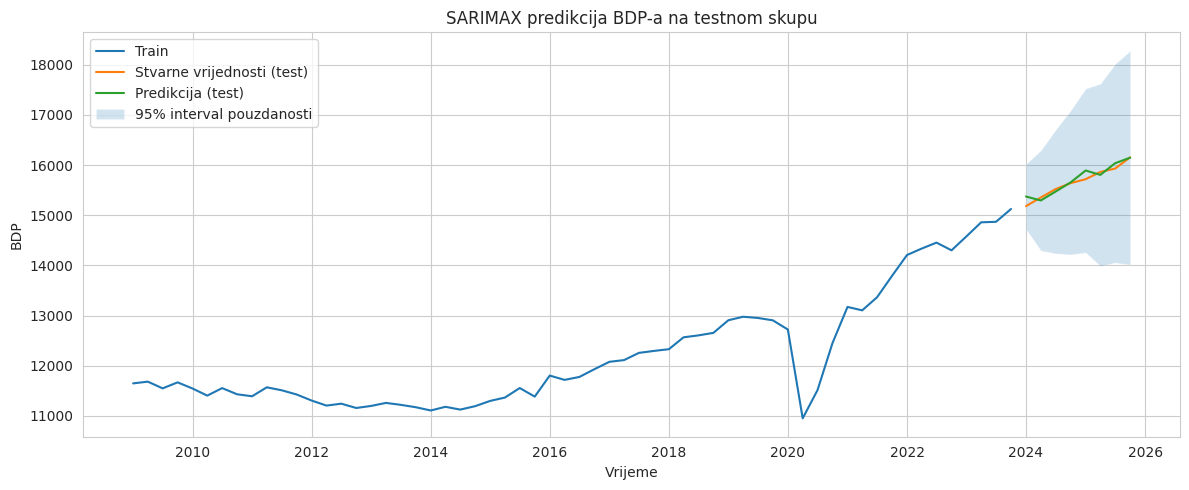


Predikcija budućih kvartala
  quarter       date  forecast_gdp      lower_ci      upper_ci
0  2026Q1 2026-01-01  16320.987695  15714.295439  16927.679952
1  2026Q2 2026-04-01  16143.069055  15228.973024  17057.165086
2  2026Q3 2026-07-01  16175.564992  15047.838699  17303.291285
3  2026Q4 2026-10-01  16270.697912  14960.379375  17581.016449


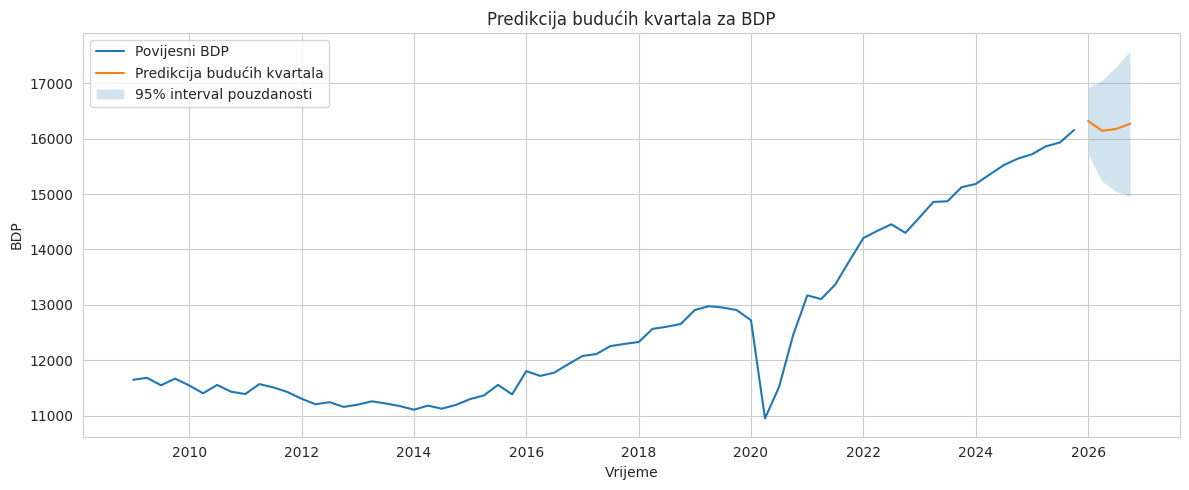


Spremljene tablice:
- annual_correlation_matrix.csv
- annual_descriptive_stats.csv
- annual_merged.csv
- annual_period_tests.csv
- future_forecast.csv
- gdp_annual_snapshot.csv
- gdp_quarterly_raw_snapshot.csv
- gdp_quarterly_snapshot.csv
- hicp_annual_snapshot.csv
- hicp_monthly_raw_snapshot.csv
- hicp_quarterly_snapshot.csv
- model_metrics.csv
- quarterly_correlation_matrix.csv
- quarterly_descriptive_stats.csv
- quarterly_merged.csv
- test_forecast_results.csv
- unemp_annual_snapshot.csv
- unemp_monthly_raw_snapshot.csv
- unemp_quarterly_raw_snapshot.csv
- unemp_quarterly_snapshot.csv

Spremljene slike:
- annual_correlation_heatmap.png
- annual_gdp.png
- annual_gdp_boxplot_covid.png
- annual_hicp.png
- annual_unemployment.png
- future_forecast_plot.png
- quarterly_correlation_heatmap.png
- quarterly_gdp.png
- quarterly_hicp.png
- quarterly_unemployment.png
- stl_decomposition_gdp.png
- test_forecast_plot.png

Spremljeni modelni sažeci:
- final_sarimax_summary.txt
- sarimax_summary.

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL

# Stil grafova
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Kreiranje izlaznih mapa
os.makedirs("output/figures", exist_ok=True)
os.makedirs("output/tables", exist_ok=True)
os.makedirs("output/models", exist_ok=True)


# =========================================================
# 1. URL-OVI ZA PODATKE
# =========================================================

# GODIŠNJI PODACI
url_gdp_annual = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nama_10_gdp"
    "?format=JSON&geo=HR&na_item=B1GQ&unit=CLV10_MEUR"
)

url_hicp_annual = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_aind"
    "?format=JSON&geo=HR&coicop=CP00"
)

url_unemp_annual = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/une_rt_a"
    "?format=JSON&geo=HR&sex=T&age=Y15-74&unit=PC_ACT"
)

# KVARTALNI / MJESEČNI PODACI
url_gdp_quarterly = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/namq_10_gdp"
    "?format=JSON&geo=HR&na_item=B1GQ&unit=CLV10_MEUR&s_adj=SCA"
)

url_hicp_monthly = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_midx"
    "?format=JSON&geo=HR&coicop=CP00&unit=I15"
)

# OVDJE JE PROMJENA:
# umjesto mjesečne nezaposlenosti koristimo kvartalnu nezaposlenost
url_unemp_quarterly = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/une_rt_q"
    "?format=JSON&lang=en&geo=HR&sex=T&age=Y15-74&unit=PC_ACT&s_adj=SA"
)


# =========================================================
# 2. POMOĆNE FUNKCIJE
# =========================================================

def fetch_eurostat_json(url: str) -> dict:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return response.json()


def eurostat_time_series_to_df(data: dict, value_name: str, time_col: str = "time") -> pd.DataFrame:
    if "dimension" not in data or time_col not in data["dimension"]:
        raise ValueError(f"JSON odgovor ne sadrži očekivanu vremensku dimenziju '{time_col}'.")

    time_index = data["dimension"][time_col]["category"]["index"]
    pos_to_time = {int(pos): label for label, pos in time_index.items()}

    rows = []
    for pos_str, value in data.get("value", {}).items():
        try:
            pos = int(pos_str)
        except ValueError:
            continue

        if pos in pos_to_time:
            rows.append({
                "time": pos_to_time[pos],
                value_name: value
            })

    if not rows:
        return pd.DataFrame(columns=["time", value_name])

    df = pd.DataFrame(rows).sort_values("time").reset_index(drop=True)
    return df


def parse_quarter_string(q_str: str) -> pd.Period:
    s = str(q_str).strip()
    if "-Q" in s:
        year, quarter = s.split("-Q")
    elif "Q" in s:
        year, quarter = s.split("Q")
    else:
        raise ValueError(f"Nepoznat kvartalni format: {q_str}")
    return pd.Period(f"{year}Q{quarter}", freq="Q")


def parse_month_string(m_str: str) -> pd.Period:
    s = str(m_str).strip()
    if "-" in s:
        return pd.Period(s, freq="M")
    elif "M" in s:
        year, month = s.split("M")
        return pd.Period(f"{year}-{int(month):02d}", freq="M")
    else:
        raise ValueError(f"Nepoznat mjesečni format: {m_str}")


def monthly_to_quarterly(df: pd.DataFrame, value_col: str, agg: str = "mean") -> pd.DataFrame:
    df = df.copy()
    df["period_m"] = df["time"].apply(parse_month_string)
    df["quarter"] = df["period_m"].dt.asfreq("Q")

    if agg == "mean":
        out = df.groupby("quarter", as_index=False)[value_col].mean()
    elif agg == "last":
        out = (
            df.sort_values("period_m")
              .groupby("quarter", as_index=False)
              .last()[["quarter", value_col]]
        )
    else:
        raise ValueError("agg mora biti 'mean' ili 'last'.")

    return out


def annual_to_df(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out["year"] = out["time"].astype(int)
    return out[["year", value_col]].sort_values("year").reset_index(drop=True)


def quarterly_to_df(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df.copy()
    out["quarter"] = out["time"].apply(parse_quarter_string)
    return out[["quarter", value_col]].sort_values("quarter").reset_index(drop=True)


def save_snapshot(df: pd.DataFrame, filename: str, n: int = 10):
    df.head(n).to_csv(filename, index=False, encoding="utf-8-sig")


def print_info(title: str, df: pd.DataFrame):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(df.head())
    print("\nBroj redaka:", len(df))
    print("Stupci:", df.columns.tolist())


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# =========================================================
# 3. GODIŠNJI PODACI
# =========================================================

gdp_annual_json = fetch_eurostat_json(url_gdp_annual)
hicp_annual_json = fetch_eurostat_json(url_hicp_annual)
unemp_annual_json = fetch_eurostat_json(url_unemp_annual)

gdp_annual_raw = eurostat_time_series_to_df(gdp_annual_json, "gdp")
hicp_annual_raw = eurostat_time_series_to_df(hicp_annual_json, "hicp")
unemp_annual_raw = eurostat_time_series_to_df(unemp_annual_json, "unemployment")

gdp_annual = annual_to_df(gdp_annual_raw, "gdp")
hicp_annual = annual_to_df(hicp_annual_raw, "hicp")
unemp_annual = annual_to_df(unemp_annual_raw, "unemployment")

print_info("Godišnji BDP", gdp_annual)
print_info("Godišnji HICP", hicp_annual)
print_info("Godišnja nezaposlenost", unemp_annual)

save_snapshot(gdp_annual, "output/tables/gdp_annual_snapshot.csv")
save_snapshot(hicp_annual, "output/tables/hicp_annual_snapshot.csv")
save_snapshot(unemp_annual, "output/tables/unemp_annual_snapshot.csv")

df_annual = (
    gdp_annual.merge(hicp_annual, on="year", how="inner")
              .merge(unemp_annual, on="year", how="inner")
              .sort_values("year")
              .reset_index(drop=True)
)

df_annual = df_annual.dropna().copy()

print_info("Zajednički godišnji skup podataka", df_annual)
df_annual.to_csv("output/tables/annual_merged.csv", index=False, encoding="utf-8-sig")

annual_desc = df_annual[["gdp", "hicp", "unemployment"]].describe()
print("\nDeskriptivna statistika - godišnji podaci")
print(annual_desc)

annual_desc.to_csv("output/tables/annual_descriptive_stats.csv", encoding="utf-8-sig")

plt.figure()
plt.plot(df_annual["year"], df_annual["gdp"])
plt.title("Godišnji realni BDP Republike Hrvatske")
plt.xlabel("Godina")
plt.ylabel("BDP")
plt.tight_layout()
plt.savefig("output/figures/annual_gdp.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_annual["year"], df_annual["hicp"])
plt.title("Godišnja inflacija (HICP) Republike Hrvatske")
plt.xlabel("Godina")
plt.ylabel("HICP")
plt.tight_layout()
plt.savefig("output/figures/annual_hicp.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_annual["year"], df_annual["unemployment"])
plt.title("Godišnja stopa nezaposlenosti Republike Hrvatske")
plt.xlabel("Godina")
plt.ylabel("Nezaposlenost (%)")
plt.tight_layout()
plt.savefig("output/figures/annual_unemployment.png", dpi=200, bbox_inches="tight")
plt.show()

corr_annual = df_annual[["gdp", "hicp", "unemployment"]].corr(method="pearson")
print("\nPearsonova korelacijska matrica - godišnji podaci")
print(corr_annual)

corr_annual.to_csv("output/tables/annual_correlation_matrix.csv", encoding="utf-8-sig")

plt.figure(figsize=(6, 4))
sns.heatmap(corr_annual, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearsonova korelacijska matrica - godišnji podaci")
plt.tight_layout()
plt.savefig("output/figures/annual_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

gdp_pre = df_annual[(df_annual["year"] >= 2015) & (df_annual["year"] <= 2019)]["gdp"]
gdp_post = df_annual[(df_annual["year"] >= 2020) & (df_annual["year"] <= 2024)]["gdp"]

t_stat, t_p = ttest_ind(gdp_pre, gdp_post, equal_var=False)
u_stat, u_p = mannwhitneyu(gdp_pre, gdp_post, alternative="two-sided")

test_results = pd.DataFrame({
    "test": ["Welch t-test", "Mann-Whitney U test"],
    "statistic": [t_stat, u_stat],
    "p_value": [t_p, u_p]
})

print("\nRezultati testiranja razlike BDP-a između razdoblja")
print(test_results)

test_results.to_csv("output/tables/annual_period_tests.csv", index=False, encoding="utf-8-sig")

plt.figure()
plt.boxplot([gdp_pre, gdp_post], labels=["2015–2019", "2020–2024"])
plt.title("Usporedba godišnjeg BDP-a prije i nakon pandemije")
plt.ylabel("BDP")
plt.tight_layout()
plt.savefig("output/figures/annual_gdp_boxplot_covid.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================================
# 4. KVARTALNI I MJESEČNI PODACI
# =========================================================

gdp_quarterly_json = fetch_eurostat_json(url_gdp_quarterly)
hicp_monthly_json = fetch_eurostat_json(url_hicp_monthly)
unemp_quarterly_json = fetch_eurostat_json(url_unemp_quarterly)

print("\nDIJAGNOSTIKA ZA KVARTALNU NEZAPOSLENOST")
print("Ključevi JSON odgovora:", unemp_quarterly_json.keys())
print("Broj zapisa u 'value':", len(unemp_quarterly_json.get("value", {})))
print("Dimension keys:", unemp_quarterly_json.get("dimension", {}).keys())

if "dimension" in unemp_quarterly_json and "time" in unemp_quarterly_json["dimension"]:
    print(
        "Prvih 10 time oznaka:",
        list(unemp_quarterly_json["dimension"]["time"]["category"]["index"].items())[:10]
    )

gdp_quarterly_raw = eurostat_time_series_to_df(gdp_quarterly_json, "gdp")
hicp_monthly_raw = eurostat_time_series_to_df(hicp_monthly_json, "hicp")
unemp_quarterly_raw = eurostat_time_series_to_df(unemp_quarterly_json, "unemployment")

print_info("Kvartalni BDP - sirovi podaci", gdp_quarterly_raw)
print_info("Mjesečni HICP - sirovi podaci", hicp_monthly_raw)
print_info("Kvartalna nezaposlenost - sirovi podaci", unemp_quarterly_raw)

save_snapshot(gdp_quarterly_raw, "output/tables/gdp_quarterly_raw_snapshot.csv")
save_snapshot(hicp_monthly_raw, "output/tables/hicp_monthly_raw_snapshot.csv")
save_snapshot(unemp_quarterly_raw, "output/tables/unemp_quarterly_raw_snapshot.csv")

gdp_quarterly = quarterly_to_df(gdp_quarterly_raw, "gdp")
hicp_quarterly = monthly_to_quarterly(hicp_monthly_raw, "hicp", agg="mean")

if unemp_quarterly_raw.empty:
    raise ValueError("Kvartalna nezaposlenost vraća prazan skup podataka.")

unemp_quarterly = quarterly_to_df(unemp_quarterly_raw, "unemployment")

print_info("Kvartalni BDP", gdp_quarterly)
print_info("Kvartalni HICP", hicp_quarterly)
print_info("Kvartalna nezaposlenost", unemp_quarterly)

save_snapshot(gdp_quarterly, "output/tables/gdp_quarterly_snapshot.csv")
save_snapshot(hicp_quarterly, "output/tables/hicp_quarterly_snapshot.csv")
save_snapshot(unemp_quarterly, "output/tables/unemp_quarterly_snapshot.csv")

df_quarterly = (
    gdp_quarterly.merge(hicp_quarterly, on="quarter", how="inner")
                 .merge(unemp_quarterly, on="quarter", how="inner")
                 .sort_values("quarter")
                 .reset_index(drop=True)
)

df_quarterly = df_quarterly.dropna().copy()
df_quarterly["date"] = df_quarterly["quarter"].dt.to_timestamp()

print_info("Zajednički kvartalni skup podataka", df_quarterly)
df_quarterly.to_csv("output/tables/quarterly_merged.csv", index=False, encoding="utf-8-sig")

quarterly_desc = df_quarterly[["gdp", "hicp", "unemployment"]].describe()
print("\nDeskriptivna statistika - kvartalni podaci")
print(quarterly_desc)

quarterly_desc.to_csv("output/tables/quarterly_descriptive_stats.csv", encoding="utf-8-sig")

plt.figure()
plt.plot(df_quarterly["date"], df_quarterly["gdp"])
plt.title("Kvartalni realni BDP Republike Hrvatske")
plt.xlabel("Vrijeme")
plt.ylabel("BDP")
plt.tight_layout()
plt.savefig("output/figures/quarterly_gdp.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_quarterly["date"], df_quarterly["hicp"])
plt.title("Kvartalni HICP Republike Hrvatske")
plt.xlabel("Vrijeme")
plt.ylabel("HICP")
plt.tight_layout()
plt.savefig("output/figures/quarterly_hicp.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(df_quarterly["date"], df_quarterly["unemployment"])
plt.title("Kvartalna stopa nezaposlenosti Republike Hrvatske")
plt.xlabel("Vrijeme")
plt.ylabel("Nezaposlenost (%)")
plt.tight_layout()
plt.savefig("output/figures/quarterly_unemployment.png", dpi=200, bbox_inches="tight")
plt.show()

corr_quarterly = df_quarterly[["gdp", "hicp", "unemployment"]].corr(method="pearson")
print("\nPearsonova korelacijska matrica - kvartalni podaci")
print(corr_quarterly)

corr_quarterly.to_csv("output/tables/quarterly_correlation_matrix.csv", encoding="utf-8-sig")

plt.figure(figsize=(6, 4))
sns.heatmap(corr_quarterly, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearsonova korelacijska matrica - kvartalni podaci")
plt.tight_layout()
plt.savefig("output/figures/quarterly_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================================
# 5. STL DEKOMPOZICIJA
# =========================================================

stl = STL(df_quarterly["gdp"], period=4, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig("output/figures/stl_decomposition_gdp.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================================
# 6. TRAIN / TEST PODJELA
# =========================================================

test_size = 8

train = df_quarterly.iloc[:-test_size].copy()
test = df_quarterly.iloc[-test_size:].copy()

y_train = train["gdp"]
y_test = test["gdp"]

X_train = train[["hicp", "unemployment"]]
X_test = test[["hicp", "unemployment"]]

print("\nVeličina train skupa:", len(train))
print("Veličina test skupa:", len(test))
print("Train raspon:", train["quarter"].min(), "->", train["quarter"].max())
print("Test raspon:", test["quarter"].min(), "->", test["quarter"].max())


# =========================================================
# 7. SARIMAX MODEL
# =========================================================

sarimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

print(sarimax_results.summary())

with open("output/models/sarimax_summary.txt", "w", encoding="utf-8") as f:
    f.write(sarimax_results.summary().as_text())


# =========================================================
# 8. PREDIKCIJA NA TESTNOM SKUPU
# =========================================================

forecast_test = sarimax_results.get_forecast(steps=len(test), exog=X_test)
y_pred = forecast_test.predicted_mean
conf_int = forecast_test.conf_int()

forecast_test_df = pd.DataFrame({
    "quarter": test["quarter"].values,
    "actual_gdp": y_test.values,
    "predicted_gdp": y_pred.values,
    "lower_ci": conf_int.iloc[:, 0].values,
    "upper_ci": conf_int.iloc[:, 1].values
})

print("\nPredikcija na testnom skupu")
print(forecast_test_df)

forecast_test_df.to_csv("output/tables/test_forecast_results.csv", index=False, encoding="utf-8-sig")


# =========================================================
# 9. EVALUACIJA MODELA
# =========================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = calculate_mape(y_test, y_pred)

metrics_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "MAPE"],
    "value": [mae, rmse, mape]
})

print("\nEvaluacijske metrike modela")
print(metrics_df)

metrics_df.to_csv("output/tables/model_metrics.csv", index=False, encoding="utf-8-sig")


# =========================================================
# 10. GRAF TESTNE PREDIKCIJE
# =========================================================

plt.figure()
plt.plot(train["date"], y_train, label="Train")
plt.plot(test["date"], y_test, label="Stvarne vrijednosti (test)")
plt.plot(test["date"], y_pred, label="Predikcija (test)")
plt.fill_between(
    test["date"],
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2,
    label="95% interval pouzdanosti"
)
plt.title("SARIMAX predikcija BDP-a na testnom skupu")
plt.xlabel("Vrijeme")
plt.ylabel("BDP")
plt.legend()
plt.tight_layout()
plt.savefig("output/figures/test_forecast_plot.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================================
# 11. FINALNI MODEL NA CIJELOM SKUPU
# =========================================================

final_model = SARIMAX(
    endog=df_quarterly["gdp"],
    exog=df_quarterly[["hicp", "unemployment"]],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

with open("output/models/final_sarimax_summary.txt", "w", encoding="utf-8") as f:
    f.write(final_results.summary().as_text())


# =========================================================
# 12. PREDIKCIJA BUDUĆIH KVARTALA
# =========================================================

future_steps = 4

last_hicp = df_quarterly["hicp"].iloc[-1]
last_unemp = df_quarterly["unemployment"].iloc[-1]

future_exog = pd.DataFrame({
    "hicp": [last_hicp] * future_steps,
    "unemployment": [last_unemp] * future_steps
})

future_forecast = final_results.get_forecast(steps=future_steps, exog=future_exog)
future_pred = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

last_quarter = df_quarterly["quarter"].max()
future_quarters = pd.period_range(start=last_quarter + 1, periods=future_steps, freq="Q")
future_dates = future_quarters.to_timestamp()

future_df = pd.DataFrame({
    "quarter": future_quarters,
    "date": future_dates,
    "forecast_gdp": future_pred.values,
    "lower_ci": future_ci.iloc[:, 0].values,
    "upper_ci": future_ci.iloc[:, 1].values
})

print("\nPredikcija budućih kvartala")
print(future_df)

future_df.to_csv("output/tables/future_forecast.csv", index=False, encoding="utf-8-sig")


# =========================================================
# 13. GRAF BUDUĆE PREDIKCIJE
# =========================================================

plt.figure()
plt.plot(df_quarterly["date"], df_quarterly["gdp"], label="Povijesni BDP")
plt.plot(future_df["date"], future_df["forecast_gdp"], label="Predikcija budućih kvartala")
plt.fill_between(
    future_df["date"],
    future_df["lower_ci"],
    future_df["upper_ci"],
    alpha=0.2,
    label="95% interval pouzdanosti"
)
plt.title("Predikcija budućih kvartala za BDP")
plt.xlabel("Vrijeme")
plt.ylabel("BDP")
plt.legend()
plt.tight_layout()
plt.savefig("output/figures/future_forecast_plot.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================================
# 14. PREGLED SPREMLJENIH REZULTATA
# =========================================================

print("\nSpremljene tablice:")
for file in sorted(os.listdir("output/tables")):
    print("-", file)

print("\nSpremljene slike:")
for file in sorted(os.listdir("output/figures")):
    print("-", file)

print("\nSpremljeni modelni sažeci:")
for file in sorted(os.listdir("output/models")):
    print("-", file)